
### Topic: Market Basket Analysis on Bakery Sales Data: An Apriori and FP-Growth Approach

📌 **Domain:** *The Bread Basket Bakery (Edinburgh)*

### Introduction

This project focuses on conducting **Market Basket Analysis (MBA)** on sales transaction data from The Bread Basket, a popular bakery in Edinburgh. The dataset, which includes over 20,500 entries across more than 9,000 unique transactions, provides a rich foundation for analyzing what items are frequently purchased together.

To uncover these valuable insights into customer purchasing habits, this analysis employs and compares two prominent data mining algorithms: the **Apriori algorithm** and the **FP-Growth (Frequent Pattern Growth) algorithm**.

* **Apriori** is a classic algorithm for finding frequent itemsets, widely recognized for its simplicity and effectiveness.
* **FP-Growth** offers a more memory-efficient and often faster alternative by using a tree structure to encode the dataset, which can be particularly advantageous for larger datasets.

By using both methods, the project aims to not only identify frequent itemsets and generate association rules but also to demonstrate and compare the performance of each algorithm. The insights gleaned from this project are directly applicable to real-world business strategy, informing key retail decisions, including:

* **Optimizing product placement** to increase sales.
* **Creating effective cross-selling opportunities** and product bundles.
* **Designing targeted promotional campaigns** based on customer behavior.
* **Improving inventory management** by anticipating demand for linked products.

Ultimately, this project highlights the power of data mining techniques to transform raw sales data into actionable business intelligence, enhancing both the customer experience and the bakery's operational efficiency.




## Import Libraries/Define Auxiliary Functions


Libraries such as Pandas, MatplotLib, SeaBorn, mlxtend and pyvis should be installed.


In [ ]:
# ! pip install pandas

In [ ]:
! pip install pyvis

In [ ]:
! pip install seaborn 

In [10]:
! pip install mlxtend 

## Download and pre-preparation of data


Some libraries should be imported before you can begin.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from pyvis.network import Network
import datetime as dt
import numpy as np


Let's download the data of customer transactions from a csv file.


In [2]:
df = pd.read_csv("bread basket.csv")
df

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend
...,...,...,...,...,...
20502,9682,Coffee,09-04-2017 14:32,afternoon,weekend
20503,9682,Tea,09-04-2017 14:32,afternoon,weekend
20504,9683,Coffee,09-04-2017 14:57,afternoon,weekend
20505,9683,Pastry,09-04-2017 14:57,afternoon,weekend


Let's study the DataSet. As you can see, the DataSet consists of 20507 rows and 5 columns. 


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


As you can see, the first column of the DataSet has int64 type. All other are of object type. 
The DataSet has the following columns:

1. Transaction: the transaction id which is unique for each order
2. Item: a list of items to be ordered/placed by customer
3. date_time: the date and time of the transaction. 
4. period_day: the period of the day when a customer ordered/placed
5. weekday_weekend: is the day is weekend (sat or sun) or a weekday.

As you can see, first of all we need to change the data type of the date_time column.


In [5]:
df['date_time']=pd.to_datetime(df['date_time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Transaction      20507 non-null  int64         
 1   Item             20507 non-null  object        
 2   date_time        20507 non-null  datetime64[ns]
 3   period_day       20507 non-null  object        
 4   weekday_weekend  20507 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 801.2+ KB


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19404\3119678500.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_time']=pd.to_datetime(df['date_time'])


We should add some new columns for basic visual market basket analysis.

To analyse purchases dynamics during different time period, we should split date_time columns into time and hours.


In [6]:
df['time']=df['date_time'].dt.time
df['hour']=df['date_time'].dt.hour

To analyse the dynamics of purchases during the year, we should add columns with month numbers and their names.


In [7]:
df['month'] = df['date_time'].dt.month
df['month name'] = df['month'].replace([1,2,3,4,5,6,7,8,9,10,11,12],['January','February','March','April','May','June','July','August','September','October','November','December'])

Similarly, to analyse weekly purchases, we need to highlight the days of the week and their names.


In [8]:
df['day'] = df['date_time'].dt.day
df['weekday'] = df['date_time'].dt.weekday
df['weekday name'] = df['weekday'].replace([0,1,2,3,4,5,6], ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

Let's analyse the final DataSet:


In [9]:
df

,Transaction,Item,date_time,period_day,weekday_weekend,time,hour,month,month name,day,weekday,weekday name
0,1,Bread,2016-10-30 09:58:00,morning,weekend,09:58:00,9,10,October,30,6,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,10:05:00,10,10,October,30,6,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,10:05:00,10,10,October,30,6,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,10:07:00,10,10,October,30,6,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,10:07:00,10,10,October,30,6,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...
20502,9682,Coffee,2017-04-09 14:32:00,afternoon,weekend,14:32:00,14,4,April,9,6,Sunday
20503,9682,Tea,2017-04-09 14:32:00,afternoon,weekend,14:32:00,14,4,April,9,6,Sunday
20504,9683,Coffee,2017-04-09 14:57:00,afternoon,weekend,14:57:00,14,4,April,9,6,Sunday
20505,9683,Pastry,2017-04-09 14:57:00,afternoon,weekend,14:57:00,14,4,April,9,6,Sunday


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Transaction      20507 non-null  int64         
 1   Item             20507 non-null  object        
 2   date_time        20507 non-null  datetime64[ns]
 3   period_day       20507 non-null  object        
 4   weekday_weekend  20507 non-null  object        
 5   time             20507 non-null  object        
 6   hour             20507 non-null  int32         
 7   month            20507 non-null  int32         
 8   month name       20507 non-null  object        
 9   day              20507 non-null  int32         
 10  weekday          20507 non-null  int32         
 11  weekday name     20507 non-null  object        
dtypes: datetime64[ns](1), int32(4), int64(1), object(6)
memory usage: 1.6+ MB


As you can see, we have 11 columns with all necessary information for preliminary visual market basket analysis.


## Data Visualizations


Let's analyze top 20 most popular purchases. 


In [11]:
popular = df['Item'].value_counts()
(df['Item'].value_counts(normalize=True)*100).head(20)

Item
Coffee           26.678695
Bread            16.213976
Tea               6.997611
Cake              4.998293
Pastry            4.174184
Sandwich          3.759692
Medialuna         3.003852
Hot chocolate     2.877066
Cookies           2.633247
Brownie           1.848149
Farm House        1.823767
Muffin            1.804262
Alfajores         1.799386
Juice             1.799386
Soup              1.667723
Scone             1.594577
Toast             1.550690
Scandinavian      1.350758
Truffles          0.941142
Coke              0.902131
Name: proportion, dtype: float64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19404\2283553626.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = popular.head(20).index, y = popular.head(20).values, palette = 'hls')


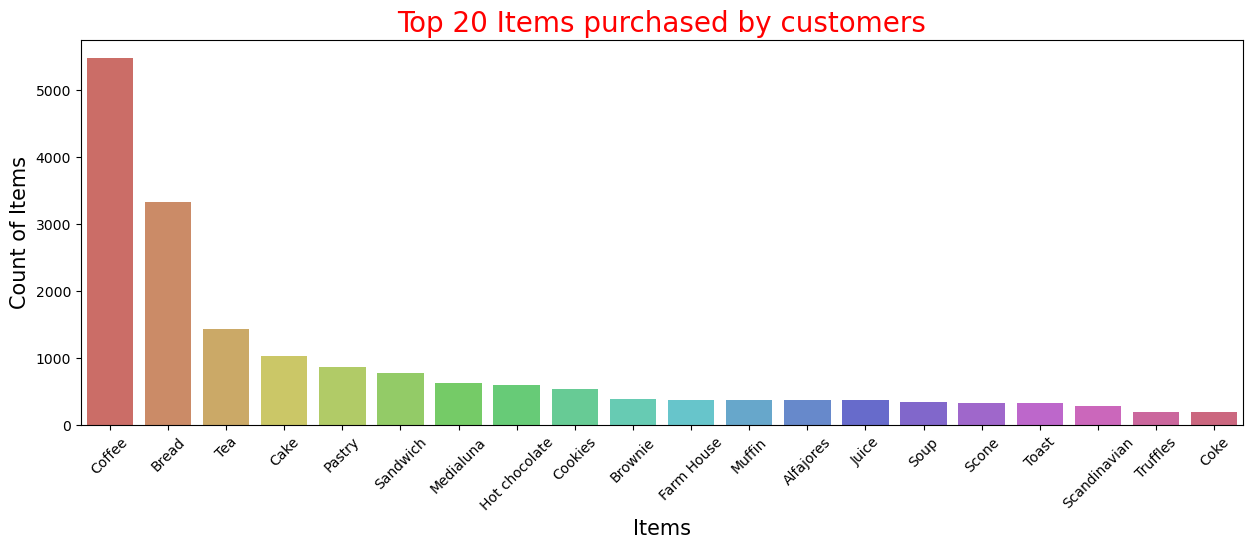

In [12]:
plt.figure(figsize=(15,5))
sns.barplot(x = popular.head(20).index, y = popular.head(20).values, palette = 'hls')
plt.xlabel('Items', size = 15)
plt.xticks(rotation=45)
plt.ylabel('Count of Items', size = 15)
plt.title('Top 20 Items purchased by customers', color = 'red', size = 20)
plt.show()

As you can see, the most popular (26%) of purchases is Coffee, the next is (16%) Bread, then goes Tea (6.99%).


Let's analyze the dynamics of monthly purchases. For correct sorting, we need to group the DataSet by month number but display on the graph by month name.


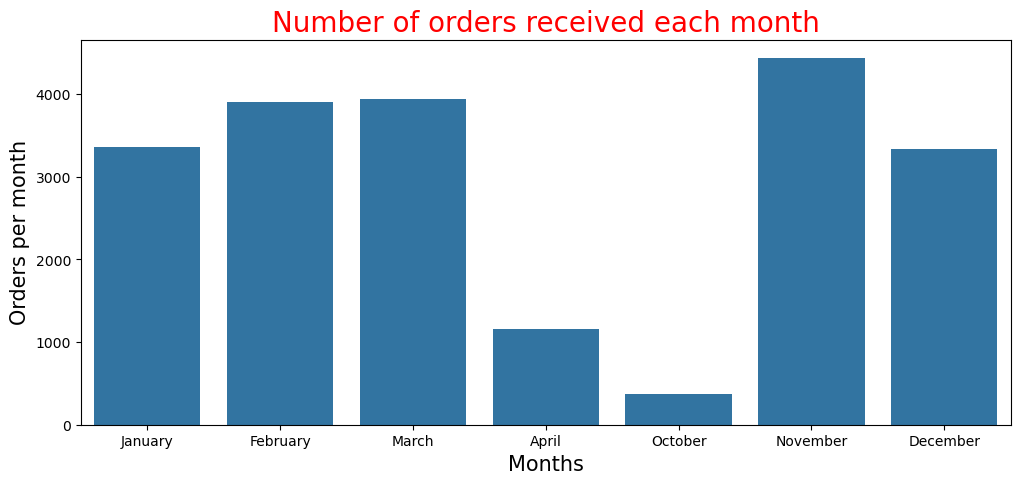

In [13]:
monthTran = df.groupby(['month','month name'])['Transaction'].count().reset_index()
plt.figure(figsize=(12,5))
sns.barplot(data = monthTran[['month name', 'Transaction']], x = "month name", y = "Transaction")
plt.xlabel('Months', size = 15)
plt.ylabel('Orders per month', size = 15)
plt.title('Number of orders received each month', color = 'red', size = 20)
plt.show()

As you can see, the largest number of purchases corresponds to March and November. Also, the most active buyers are in winter. In summer and early autumn, activity is the lowest.


Let's analyze the weekly activity. 


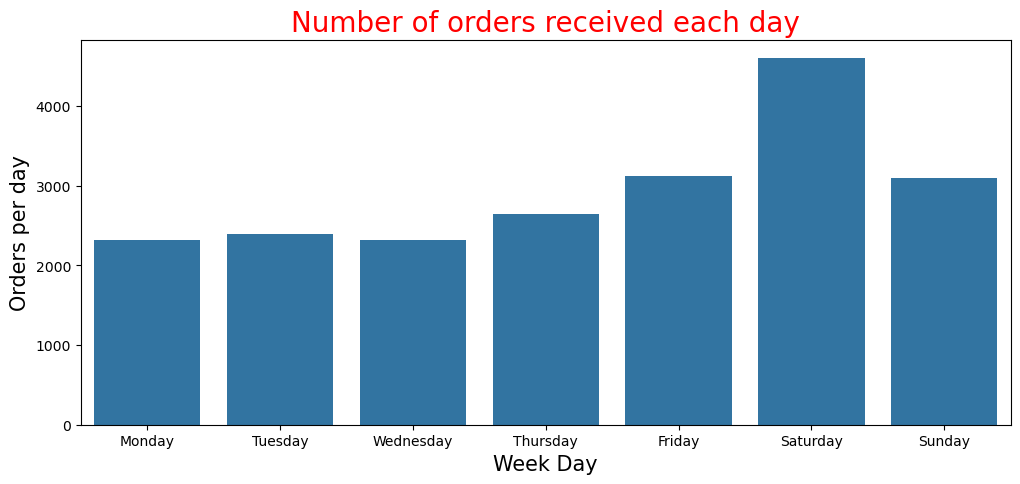

In [14]:
weekTran = df.groupby(['weekday','weekday name'])['Transaction'].count().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data = weekTran[['weekday name', 'Transaction']], x = "weekday name", y = "Transaction")
plt.xlabel('Week Day', size = 15)
plt.ylabel('Orders per day', size = 15)
plt.title('Number of orders received each day', color = 'red', size = 20)
plt.show()

As you can see from the plot, buyers are active throughout the week. There are no days with no purchases. You can see that the maximum number of purchases falls upon Saturday.

Let's analyze the share of purchases on weekends and weekdays.


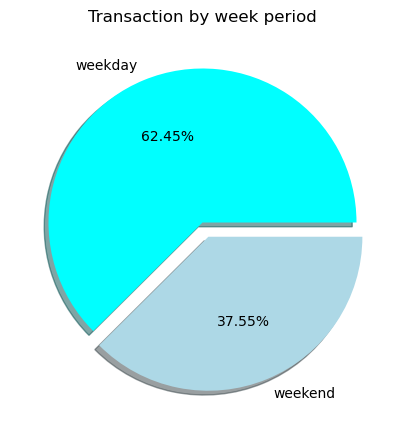

In [15]:
size = size = df['weekday_weekend'].value_counts()
labels = size.index.values
colors = ["cyan", "lightblue"]
explode = [0, 0.1]

plt.figure(figsize=(12,5))
plt.pie(size, labels = labels, colors = colors, explode = explode, shadow = True, autopct = "%.2f%%")
plt.title('Transaction by week period')
plt.show()

You can see that 62% of purchases are made on weekdays and 37% are made at the weekend.


It is also interesting to study the activity of consumers during the day.


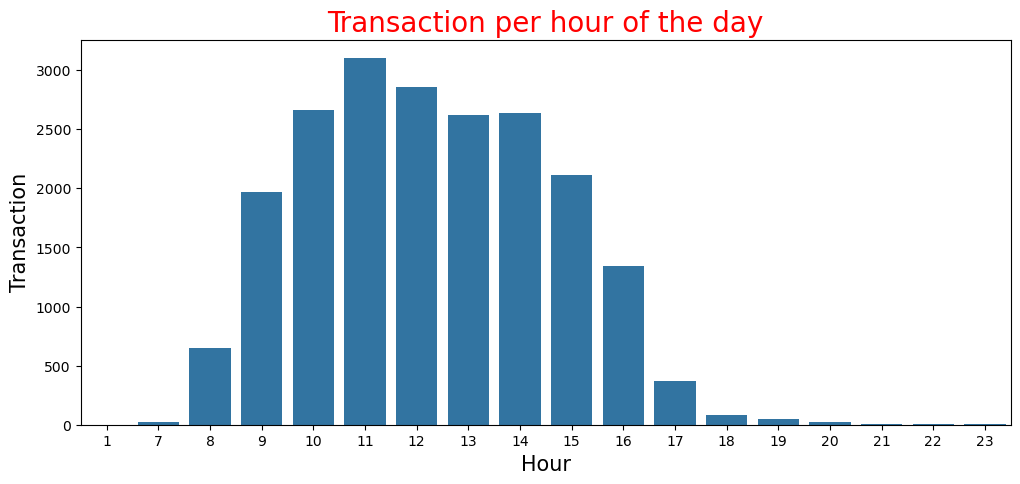

In [16]:
coutbyhour=coutbyhour=df.groupby('hour')['Transaction'].count().reset_index()
coutbyhour.sort_values('hour',inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data=coutbyhour, x='hour', y='Transaction')
plt.xlabel('Hour', size = 15)
plt.ylabel('Transaction', size = 15)
plt.title('Transaction per hour of the day', color = 'red', size = 20)
plt.show()

It is clearly seen that consumers become the most active starting from 9 in the morning to 4 in the evening.


Let's analyze the activity of buyers during parts of the day. This information is the initial DataSet. All you need to do is to add your own sort order to display the graph columns correctly.


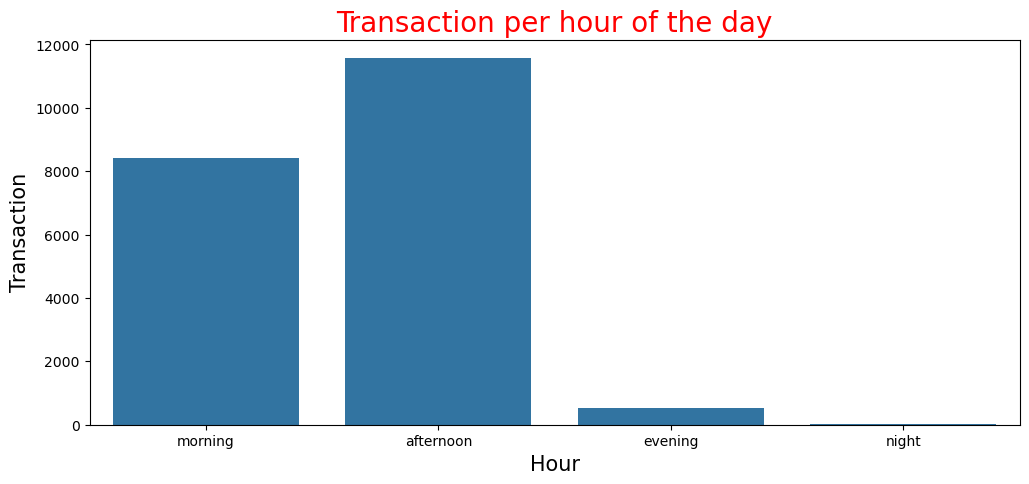

In [17]:
coutbyweekday=coutbyweekday=df.groupby('period_day')['Transaction'].count().reset_index()
coutbyweekday.loc[:,"dayorder"] = [1, 2, 0, 3]
coutbyweekday.sort_values("dayorder",inplace=True)
plt.figure(figsize=(12,5))
sns.barplot(data=coutbyweekday, x='period_day', y='Transaction')
plt.xlabel('Hour', size = 15)
plt.ylabel('Transaction', size = 15)
plt.title('Transaction per hour of the day', color = 'red', size = 20)
plt.show()

The graph confirms that buyers become most active during the afternoon.


## Association Rules


Defining the relationship between purchases is necessary to build association rules. To do this, it is necessary to transform the transaction DataSet into a special table. Columns of this table contain types of purchases and rows are transactions. Cells of this table should be bool (true/false). There are two most common ways to do this.


### Way 1. Pivot table


This way involves the use of classical pandas methods like pivot_table and group_by.

First of all, we group rows into transactions:


In [18]:
transactions = df.groupby(['Transaction', 'Item'])['Item'].count().reset_index(name ='Count')
transactions

,Transaction,Item,Count
0,1,Bread,1
1,2,Scandinavian,2
2,3,Cookies,1
3,3,Hot chocolate,1
4,3,Jam,1
...,...,...,...
18882,9682,Tacos/Fajita,1
18883,9682,Tea,1
18884,9683,Coffee,1
18885,9683,Pastry,1


In [24]:
# Convert counts to 0/1 (True/False) for presence of an item
basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)
basket_sets.head()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19404\4118536725.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)


Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Then transform this DataSet by pivot_table into a necessary market basket structure:


In [25]:
basket = transactions.pivot_table(index='Transaction', columns='Item', values='Count', aggfunc='sum').fillna(0)
basket

Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9682,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Next, we should change non-zero data to True and zero data to False:


In [22]:
def encode_units(x): 
    if(x==0): 
        return False
    if(x>0): 
        return True
    
basket_sets = basket.applymap(encode_units)
basket_sets

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19404\3229151556.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)


Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9680,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9681,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
9682,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


This is a necessary market basket DataSet that contains information about 9465 clients and 94 types of purchases.


### Way 2. Using mlxtend framework


The classic machine learning library scikit-learn does not contain association rules functions. That's why we will use the **[mlxtend](http://rasbt.github.io/mlxtend/)** (machine learning extensions) framework. It is a Python library of useful ML tools.

First of all, we should create a list of transactions each of which is a lists of purchases.


In [28]:
transactions=[]
for item in df['Transaction'].unique():
    lst=list(set(df[df['Transaction']==item]['Item']))
    transactions.append(lst)

transactions[0:10]

[['Bread'],
 ['Scandinavian'],
 ['Jam', 'Hot chocolate', 'Cookies'],
 ['Muffin'],
 ['Bread', 'Pastry', 'Coffee'],
 ['Pastry', 'Muffin', 'Medialuna'],
 ['Pastry', 'Coffee', 'Tea', 'Medialuna'],
 ['Bread', 'Pastry'],
 ['Bread', 'Muffin'],
 ['Scandinavian', 'Medialuna']]

Then we can easily get a market basket DataSet using **[TransactionEncoder()](http://rasbt.github.io/mlxtend/user_guide/preprocessing/TransactionEncoder/#transactionencoder)**.


In [29]:
te = TransactionEncoder()
encodedData = te.fit(transactions).transform(transactions)
basket_sets_2 = pd.DataFrame(encodedData, columns=te.columns_)
basket_sets_2

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9460,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9461,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
9462,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9463,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Apriori Algorithm 

As you can see, we got the same DataSet.

Now when the data is structured properly, we can generate frequent item sets for association rule mining that have an appropriate support (1% in our case) using **[apriori()](http://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/)**.

Apriori is a popular algorithm  for extracting frequent itemsets with applications in association rule learning. The apriori algorithm has been designed to operate on databases containing transactions, such as purchases by customers of a store. An itemset is considered as "frequent" if it meets a user-specified support threshold. For instance, if the support threshold is set to 0.5 (50%), a frequent itemset is defined as a set of items that occur together in at least 50% of all transactions in the database.


In [30]:
# ==============================
# Apriori Algorithm
# ==============================
frequentItems = apriori(basket_sets, use_colnames=True, min_support=0.01)
frequentItems = frequentItems.sort_values("support", ascending=False)

print("Apriori Itemsets:")
display(frequentItems.head(10))

rules = association_rules(frequentItems, metric="lift", min_threshold=1.0)
print("\nApriori Rules:")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Apriori Itemsets:


C:\Users\ASUS\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
6,0.478394,(Coffee)
2,0.327205,(Bread)
26,0.142631,(Tea)
4,0.103856,(Cake)
34,0.090016,"(Bread, Coffee)"
19,0.086107,(Pastry)
21,0.071844,(Sandwich)
16,0.061807,(Medialuna)
12,0.058320,(Hot chocolate)
42,0.054728,"(Cake, Coffee)"



Apriori Rules:


,antecedents,consequents,support,confidence,lift
0,(Cake),(Coffee),0.054728,0.526958,1.101515
1,(Coffee),(Cake),0.054728,0.114399,1.101515
2,(Pastry),(Coffee),0.047544,0.552147,1.154168
3,(Coffee),(Pastry),0.047544,0.099382,1.154168
4,(Coffee),(Sandwich),0.038246,0.079947,1.112792
5,(Sandwich),(Coffee),0.038246,0.532353,1.112792
6,(Coffee),(Medialuna),0.035182,0.073542,1.189878
7,(Medialuna),(Coffee),0.035182,0.569231,1.189878
8,(Coffee),(Hot chocolate),0.029583,0.061837,1.060311
9,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311


### FP-Growth Algorithm: 

In [31]:
# ==============================
# FP-Growth Algorithm
# ==============================
frequentItems_fp = fpgrowth(basket_sets, use_colnames=True, min_support=0.01)
frequentItems_fp = frequentItems_fp.sort_values("support", ascending=False)

print("\nFP-Growth Itemsets:")
display(frequentItems_fp.head(10))

rules_fp = association_rules(frequentItems_fp, metric="lift", min_threshold=1.0)
print("\nFP-Growth Rules:")
display(rules_fp[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


C:\Users\ASUS\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(



FP-Growth Itemsets:


,support,itemsets
6,0.478394,(Coffee)
0,0.327205,(Bread)
9,0.142631,(Tea)
16,0.103856,(Cake)
30,0.090016,"(Bread, Coffee)"
7,0.086107,(Pastry)
18,0.071844,(Sandwich)
8,0.061807,(Medialuna)
2,0.058320,(Hot chocolate)
46,0.054728,"(Cake, Coffee)"



FP-Growth Rules:


,antecedents,consequents,support,confidence,lift
0,(Cake),(Coffee),0.054728,0.526958,1.101515
1,(Coffee),(Cake),0.054728,0.114399,1.101515
2,(Pastry),(Coffee),0.047544,0.552147,1.154168
3,(Coffee),(Pastry),0.047544,0.099382,1.154168
4,(Coffee),(Sandwich),0.038246,0.079947,1.112792
5,(Sandwich),(Coffee),0.038246,0.532353,1.112792
6,(Coffee),(Medialuna),0.035182,0.073542,1.189878
7,(Medialuna),(Coffee),0.035182,0.569231,1.189878
8,(Coffee),(Hot chocolate),0.029583,0.061837,1.060311
9,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311


### Comparison of Results Between Apriori and FP-Growth Algorithm: 

In [32]:
# Compare Results
# ==============================
print("\nApriori found:", len(frequentItems), "itemsets")
print("FP-Growth found:", len(frequentItems_fp), "itemsets")
print("Apriori rules:", len(rules))
print("FP-Growth rules:", len(rules_fp))


Apriori found: 61 itemsets
FP-Growth found: 61 itemsets
Apriori rules: 42
FP-Growth rules: 42


### Metrics


The currently supported metrics for evaluating association rules and setting selection thresholds are listed below. Given a rule "A → C", A stands for antecedent and C stands for consequent.


_Support_

The support metric is defined for itemsets, not association rules. The table produced by the association rule mining algorithm contains three different support metrics: 'antecedent support', 'consequent support', and 'support'. Here, 'antecedent support' computes the proportion of transactions that contain the antecedent A, and 'consequent support' computes the support for the itemset of the consequent C. The 'support' metric then computes the support of the combined itemset A∪C - note that 'support' depends on 'antecedent support' and 'consequent support' via min('antecedent support', 'consequent support').

Typically, support is used to measure the abundance or frequency (often interpreted as significance or importance) of an itemset in a database. We refer to an itemset as a "frequent itemset" if its support is larger than a specified minimum-support threshold. Note that in general, due to the downward closure property, all subsets of a frequent itemset are also frequent.


_Confidence_

The confidence of a rule A->C is the probability of seeing the consequent in a transaction given that it also contains the antecedent. Note that the metric is not symmetric or directed; for instance, the confidence for A->C is different than the confidence for C->A. The confidence is 1 (maximal) for a rule A->C if the consequent and antecedent always occur together.


_Lift_

The lift metric is commonly used to measure how much more often the antecedent and consequent of a rule A->C occur together than we would expect if they were statistically independent. If A and C are independent, the Lift score will be exactly 1.


_Leverage_

Leverage computes the difference between the observed frequency of A and C appearing together and the frequency that would be expected if A and C were independent. A leverage value of 0 indicates independence.


_Conviction_

A high conviction value means that the consequent is highly depending on the antecedent. For instance, in the case of a perfect confidence score, the denominator becomes 0 (due to 1 - 1) for which the conviction score is defined as 'inf'. Similar to lift, if items are independent, the conviction is 1.


"Generating and Filtering Association Rules"

In [33]:
rules = association_rules(frequentItems, metric="confidence", min_threshold=0.2)
rules.sort_values('confidence', ascending=False, inplace=True)
rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
10,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
25,(Spanish Brunch),(Coffee),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
5,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
3,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
14,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
12,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
4,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
1,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
16,(Scone),(Coffee),0.034548,0.478394,0.018067,0.522936,1.093107,1.0,0.001539,1.093366,0.088224,0.036507,0.085393,0.280350
8,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707


This data set contains all possible causal relationships.  

Let's see all rules that have lift>1:


In [34]:
rules[rules["lift"]>1].sort_values("support",ascending = False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
3,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
4,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
5,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
6,(Hot chocolate),(Coffee),0.058320,0.478394,0.029583,0.507246,1.060311,1.0,0.001683,1.058553,0.060403,0.058333,0.055314,0.284542
7,(Pastry),(Bread),0.086107,0.327205,0.029160,0.338650,1.034977,1.0,0.000985,1.017305,0.036980,0.075908,0.017011,0.213884
8,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707
9,(Cake),(Tea),0.103856,0.142631,0.023772,0.228891,1.604781,1.0,0.008959,1.111865,0.420538,0.106736,0.100611,0.197779
10,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
12,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656


Imagine a situation where a customer buys a Cake. Let's predict what else they can buy:


In [37]:
rules[rules['antecedents'] == frozenset({'Cake'})]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
11,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
12,(Cake),(Tea),0.103856,0.142631,0.023772,0.228891,1.604781,1.0,0.008959,1.111865,0.420538,0.106736,0.100611,0.197779
3,(Cake),(Bread),0.103856,0.327205,0.023349,0.224822,0.687097,1.0,-0.010633,0.867923,-0.336947,0.057269,-0.152177,0.148091


As you can see, there are three possible options:
1. Coffee - 47%
2. Tea - 14%
3. Bread - 3%


This can be a recommendation of which product should be placed closer to or farther from the cake on the shelves. Depending on the strategy of the supermarket.


Let's analyse which products are bought together the most frequently.


In [36]:
frequentItems["antecedent_len"] = frequentItems["itemsets"].apply(lambda x: len(x))
frequentItems[frequentItems["antecedent_len"]>1].sort_values(by=["antecedent_len","support"], ascending=False)

,support,itemsets,antecedent_len
59,0.011199,"(Bread, Pastry, Coffee)",3
58,0.010037,"(Bread, Cake, Coffee)",3
60,0.010037,"(Cake, Coffee, Tea)",3
34,0.090016,"(Bread, Coffee)",2
42,0.054728,"(Cake, Coffee)",2
55,0.049868,"(Coffee, Tea)",2
50,0.047544,"(Pastry, Coffee)",2
51,0.038246,"(Coffee, Sandwich)",2
48,0.035182,"(Coffee, Medialuna)",2
46,0.029583,"(Coffee, Hot chocolate)",2


The confidence for a very frequent consequent is always high even if there is a very weak association. So, this doesn't give us a clearer picture. Here, coffee is by far the most frequent item and the best seller. It can therefore be recommended anyway with every other item. So, we can drop the rules recommending coffee to get a clearer picture of the real unknown rules generated from the data.


In [39]:
index_names = rules['consequents'] == frozenset({'Coffee'})
refinedRules = rules[~index_names].sort_values('lift', ascending=False)
refinedRules.drop(['leverage','conviction'], axis=1, inplace=True)
refinedRules = refinedRules.reset_index()
refinedRules

,index,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,zhangs_metric,jaccard,certainty,kulczynski
0,29,"(Coffee, Tea)",(Cake),0.049868,0.103856,0.010037,0.201271,1.937977,1.0,0.509401,0.069853,0.108705,0.148957
1,12,(Cake),(Tea),0.103856,0.142631,0.023772,0.228891,1.604781,1.0,0.420538,0.106736,0.100611,0.197779
2,25,(Sandwich),(Tea),0.071844,0.142631,0.014369,0.200000,1.402222,1.0,0.309050,0.071806,0.066913,0.150370
3,8,(Pastry),(Bread),0.086107,0.327205,0.029160,0.338650,1.034977,1.0,0.036980,0.075908,0.017011,0.213884
4,0,(Alfajores),(Bread),0.036344,0.327205,0.010354,0.284884,0.870657,1.0,-0.133570,0.029315,-0.062904,0.158264
5,7,(Medialuna),(Bread),0.061807,0.327205,0.016904,0.273504,0.835879,1.0,-0.173062,0.045429,-0.079818,0.162584
6,2,(Brownie),(Bread),0.040042,0.327205,0.010777,0.269129,0.822508,1.0,-0.183536,0.030231,-0.086321,0.151032
7,5,(Cookies),(Bread),0.054411,0.327205,0.014474,0.266019,0.813004,1.0,-0.195651,0.039424,-0.090943,0.155128
8,9,(Sandwich),(Bread),0.071844,0.327205,0.017010,0.236765,0.723596,1.0,-0.291561,0.044524,-0.134426,0.144375
9,27,"(Pastry, Coffee)",(Bread),0.047544,0.327205,0.011199,0.235556,0.719901,1.0,-0.290026,0.030805,-0.136223,0.134891


Now the relationship between other types of goods is visible more clearly, such as Cake -> Tea or (Tea and Coffee) -> Cake


## Visualization of Association Rules


An important issue of analysis and understanding of associative rules is the possibility of their visualization. There are several approaches to this. However, the most clear and obvious is the use of the library **[pyvis](https://pyvis.readthedocs.io/en/latest/)**. This is a special framework for Interactive network visualizations.


First of all, we should create a pyvis **[Network()](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=Network#pyvis.network.Network)**. The Network class is the focus of this library. All pyvis functionality should be implemented off of a Network instance.


In [40]:
Basket_Network = Network(height="1000px", width="1000px", directed=True, notebook=True)

Then we should choose the type of pyvis network. There are several types such as: **[force_atlas_2based()](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=repulsion#pyvis.network.Network.repulsion)**, **[barnes_hut()](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=repulsion#pyvis.network.Network.repulsion)**, **[hrepulsion()](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=repulsion#pyvis.network.Network.repulsion)**, **[repulsion()](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=repulsion#pyvis.network.Network.repulsion)**, **[etc](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=repulsion#pyvis.network.Network.repulsion)**.


In [41]:
# Basket_Network.force_atlas_2based()
# Basket_Network.barnes_hut()
# Basket_Network.hrepulsion()
Basket_Network.repulsion()

Then we should create nodes (**[add_node()](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=add_node#pyvis.network.Network.add_node)**) and eges (**[add_edge()](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=add_edge#pyvis.network.Network.add_edge)**) between them for a pyvis graph based on rules:


In [42]:
Basket_Network_Data_zip=zip(rules["antecedents"],
                            rules["consequents"],
                            rules["antecedent support"],
                            rules["consequent support"],
                            rules["confidence"])

for i in Basket_Network_Data_zip:
    FromItem=str(i[0]).replace("frozenset({'","").replace("'})","").replace("',　'",",")
    ToItem=str(i[1]).replace("frozenset({'","").replace("'})","").replace("',　'",",")
    FromWeight=i[2]
    ToWeight=i[3]
    EdgeWeight=i[4]

    Basket_Network.add_node(n_id=FromItem, shape="dot", value=FromWeight,
                            title=FromItem + "<br>Support: " + str(FromWeight))
    Basket_Network.add_node(n_id=ToItem, shape="dot", value=ToWeight,
                           title=ToItem + "<br>Support: " + str(ToWeight))
    Basket_Network.add_edge(source=FromItem, to=ToItem, value=EdgeWeight, arrowStrikethrough=False,
                            title=FromItem + " --> " + ToItem + "<br>Confidence:" + str(EdgeWeight))

Then we should set the edges smooth (**[set_edge_smooth](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=set_edge_smooth#pyvis.network.Network.set_edge_smooth)**) and set the parameters of visualizations like **[toggle_hide_edges_on_drag](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=toggle_hide_edges_on_drag#pyvis.network.Network.toggle_hide_edges_on_drag)**.


In [45]:
Basket_Network.set_edge_smooth(smooth_type="continuous")
Basket_Network.toggle_hide_edges_on_drag(True)

The last step - we save the graph into a file and visualize it using **[save_graph()](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=save_graph#pyvis.network.Network.save_graph)** and **[show()](https://pyvis.readthedocs.io/en/latest/documentation.html?highlight=show#pyvis.network.Network.show)**.


In [47]:
Basket_Network.save_graph("Basket_Network1.html")
Basket_Network.show("Basket_Network1.html")

Basket_Network1.html


As you can see, the graph allows you to easily understand all races together. The width of lines show you the confidence of rule, the size of node indicate support.


Let's do the same for refinedRules:


In [54]:
Basket_Network2 = Network(height="1000px", width="1000px", directed=True, notebook=True, cdn_resources='in_line')
Basket_Network2.repulsion()
Basket_Network_Data2_zip = zip(refinedRules["antecedents"],
                            refinedRules["consequents"],
                            refinedRules["antecedent support"],
                            refinedRules["consequent support"],
                            refinedRules["confidence"])


for i in Basket_Network_Data2_zip:
    FromItem=str(i[0]).replace("frozenset({'","").replace("'})","").replace("',　'",",")
    ToItem=str(i[1]).replace("frozenset({'","").replace("'})","").replace("',　'",",")
    FromWeight=i[2]
    ToWeight=i[3]
    EdgeWeight=i[4]

    Basket_Network2.add_node(n_id=FromItem, shape="dot", value=FromWeight,
                            title=FromItem + "<br>Support: " + str(FromWeight))
    Basket_Network2.add_node(n_id=ToItem, shape="dot", value=ToWeight,
                           title=ToItem + "<br>Support: " + str(ToWeight))
    Basket_Network2.add_edge(source=FromItem, to=ToItem, value=EdgeWeight, arrowStrikethrough=False,
                            title=FromItem + " --> " + ToItem + "<br>Confidence:" + str(EdgeWeight))

Basket_Network2.set_edge_smooth(smooth_type="continuous")
Basket_Network2.toggle_hide_edges_on_drag(True)

# Fix: Save with explicit UTF-8 encoding
with open("Basket_Network2.html", "w", encoding="utf-8") as f:
    f.write(Basket_Network2.generate_html())

# Display the network
from IPython.display import IFrame
IFrame(src="Basket_Network2.html", width=1000, height=1000)

# Assistant
This error occurs because there are Unicode characters in your data that cannot be encoded using the default character encoding when saving the HTML file.

The error specifically mentions a 'charmap' codec error, which typically happens when trying to write non-ASCII characters to a file using an encoding that doesn't support those characters.

Would you like me to provide the corrected code?

# User
fix the code

In [62]:
# Assistant
Basket_Network2 = Network(height="1000px", width="1000px", directed=True, notebook=True, cdn_resources='in_line')
Basket_Network2.repulsion()
Basket_Network_Data2_zip = zip(refinedRules["antecedents"],
                            refinedRules["consequents"],
                            refinedRules["antecedent support"],
                            refinedRules["consequent support"],
                            refinedRules["confidence"])


for i in Basket_Network_Data2_zip:
    # Clean up the strings and handle potential Unicode characters
    FromItem=str(i[0]).replace("frozenset({'","").replace("'})","").replace("',　'",",")
    ToItem=str(i[1]).replace("frozenset({'","").replace("'})","").replace("',　'",",")
    FromWeight=i[2]
    ToWeight=i[3]
    EdgeWeight=i[4]

    Basket_Network2.add_node(n_id=FromItem, shape="dot", value=FromWeight,
                            title=FromItem + "<br>Support: " + str(FromWeight))
    Basket_Network2.add_node(n_id=ToItem, shape="dot", value=ToWeight,
                           title=ToItem + "<br>Support: " + str(ToWeight))
    Basket_Network2.add_edge(source=FromItem, to=ToItem, value=EdgeWeight, arrowStrikethrough=False,
                            title=FromItem + " --> " + ToItem + "<br>Confidence:" + str(EdgeWeight))

Basket_Network2.set_edge_smooth(smooth_type="continuous")
Basket_Network2.toggle_hide_edges_on_drag(True)

# Generate the HTML content first
html_content = Basket_Network2.generate_html()

# Fix: Use 'utf-8' encoding and error handling strategy
with open("Basket_Network2.html", "w", encoding="utf-8", errors="xmlcharrefreplace") as f:
    f.write(html_content)
    
# Use a browser to display the file instead of the built-in show method
import webbrowser
webbrowser.open("Basket_Network2.html")

True

### Conclusion

This project successfully applied **Market Basket Analysis** to the sales data from The Bread Basket, leveraging both the **Apriori** and **FP-Growth** algorithms to uncover significant insights into customer purchasing behavior.

Through our analysis, we identified key association rules that reveal strong relationships between different products. For instance, the high confidence of rules like `{Coffee} -> {Pastry}` or `{Toast} -> {Coffee}` confirms common purchasing patterns, providing actionable intelligence for the bakery.

The use of both the Apriori and FP-Growth algorithms proved to be a valuable comparative exercise. While Apriori provided a clear and intuitive approach to finding frequent itemsets, the FP-Growth algorithm demonstrated its efficiency by generating these patterns without the computational overhead of candidate generation, making it a powerful alternative for larger datasets.

Ultimately, the insights derived from this analysis are directly translatable into business strategy. By understanding which items are frequently bought together, the bakery can implement data-driven decisions on **store layout**, **product bundling**, and **targeted marketing campaigns** to increase sales and enhance the customer experience. This project serves as a clear example of how fundamental data mining techniques can yield a tangible business impact.